<a href="https://colab.research.google.com/github/DhairyaDave08/BetaData-SpaceX/blob/main/Notebooks/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Space Mission Risk Analytics: Exploratory Data Analysis (EDA)**

## **Executive Summary**
Space launch is one of the most engineering-intensive and risk-laden activities humans undertake. A single launch campaign can cost upwards of $400 million, and a failure destroys both the vehicle and its payload.

In this notebook, we perform an Exploratory Data Analysis (EDA) on historical space missions from 1957 to present. Our goal is to understand the underlying distributions, identify data quality issues (such as missing cost data), and formulate a strategy for building a **Calibrated Mission Success Predictor**.

### Key Challenges Identified for Modeling:
1. **Severe Class Imbalance:** ~90% of modern missions succeed.
2. **Temporal Bias:** Early decades (1960s) had much higher failure rates than the 2010s.
3. **High Cardinality:** There are hundreds of unique rocket families and launch sites, many with very few launches.

## 1. Environment Setup & Data Ingestion
First, we will clone the repository containing our custom data loaders and install the required dependencies.

In [11]:
!git clone https://github.com/DhairyaDave08/BetaData-SpaceX.git
%cd BetaData-SpaceX
!pip install -q -r requirements.txt

import sys
sys.path.append('/content/BetaData-SpaceX')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

from src.data_loader import load_raw_data, clean_dataset, data_quality_report

Cloning into 'BetaData-SpaceX'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 29 (delta 7), reused 17 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 108.53 KiB | 617.00 KiB/s, done.
Resolving deltas: 100% (7/7), done.
/content/BetaData-SpaceX/BetaData-SpaceX


## 2. Initial Data Assessment & Quality Report
We load the raw dataset and pass it through our cleaning pipeline. The data quality report will highlight missing values and overall summary statistics.

In [12]:
raw = load_raw_data("Data/Raw/Space_Corrected.csv")
df = clean_dataset(raw)

report = data_quality_report(df)
for k, v in report.items():
    print(f"{k}: {v}")

Dropped 126 rows with missing target/date out of 4324
total_rows: 4198
missing_by_column: {'company_name': 0, 'location': 0, 'datum': 0, 'detail': 0, 'status_rocket': 0, 'rocket': 3240, 'status_mission': 0, 'launch_date': 0, 'year': 0, 'decade': 0, 'rocket_family': 0, 'payload_desc': 0, 'country': 0, 'launch_site': 0, 'cost_musd': 3240, 'mission_success': 0}
year_range: (1957, 2020)
unique_rocket_families: 339
unique_launch_sites: 126
unique_countries: 21
success_rate_overall: 0.9038
rows_per_decade: {1950.0: 45, 1960.0: 752, 1970.0: 983, 1980.0: 607, 1990.0: 627, 2000.0: 464, 2010.0: 657, 2020.0: 63}
cost_missing_pct: 77.2


In [14]:
import os
os.makedirs("data/processed", exist_ok=True)

df.to_csv("data/processed/launches_clean.csv", index=False)

## 3. Target Variable Analysis: Class Imbalance
Our primary objective is to predict mission success. Let's look at the raw breakdown of mission statuses before they were binarized.

**Observation:** The dataset is heavily imbalanced. Because over 90% of missions succeed, a naive model that always predicts "Success" would be 90% accurate but entirely useless for risk analytics. We will need to optimize for **Recall** and **PR-AUC**, and use probability calibration (Platt scaling or Isotonic regression) to ensure our risk scores are trustworthy.

/tmp/ipykernel_495/364001129.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=raw["Status Mission"].value_counts().values,


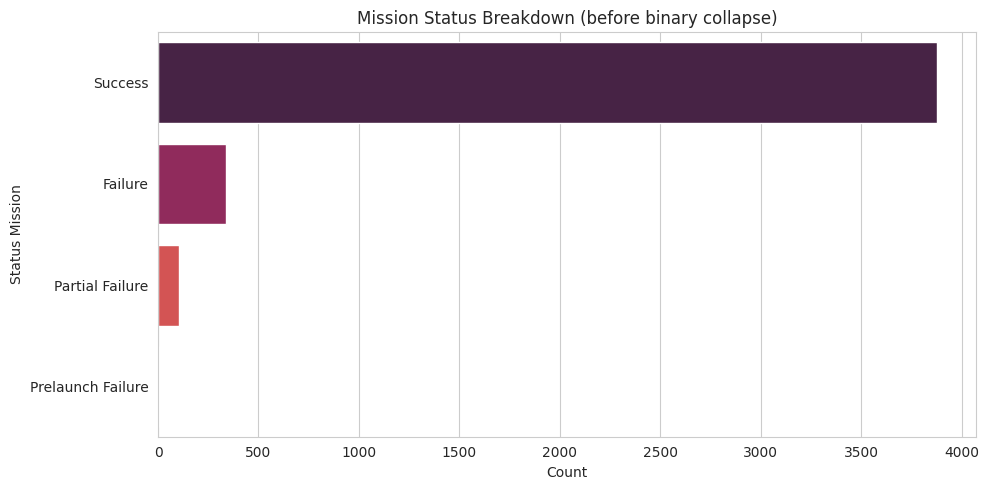

In [15]:
fig, ax = plt.subplots()
sns.barplot(x=raw["Status Mission"].value_counts().values,
            y=raw["Status Mission"].value_counts().index, ax=ax, palette="rocket")
ax.set_xlabel("Count")
ax.set_title("Mission Status Breakdown (before binary collapse)")
plt.tight_layout()
plt.show()

## 4. Temporal Dynamics: The Evolution of Spaceflight
Space technology has matured drastically since the Space Race of the 1960s. If we don't account for this temporal shift, our model will overestimate the risk of modern rockets by unfairly judging them against 1960s failure rates.

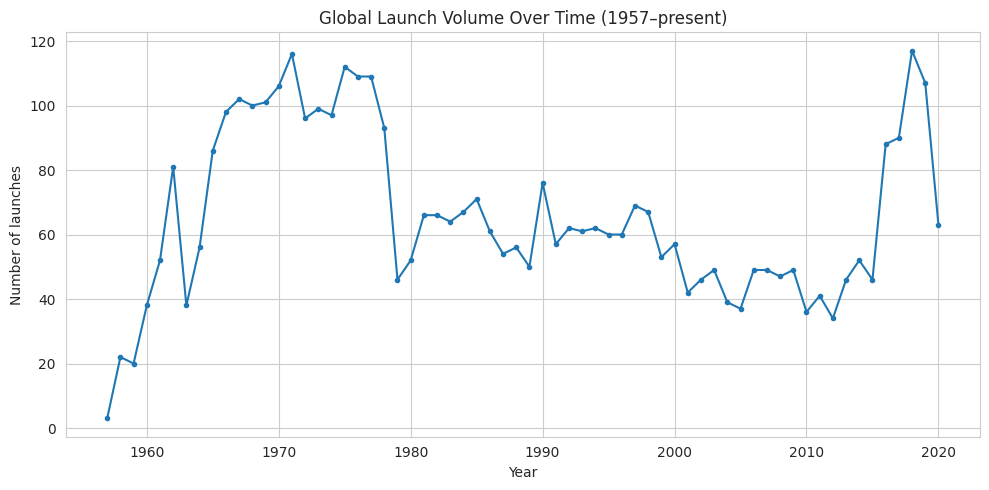

In [16]:
yearly = df.groupby("year").size()
fig, ax = plt.subplots()
ax.plot(yearly.index, yearly.values, marker="o", markersize=3)
ax.set_xlabel("Year")
ax.set_ylabel("Number of launches")
ax.set_title("Global Launch Volume Over Time (1957–present)")
plt.tight_layout()
plt.show()

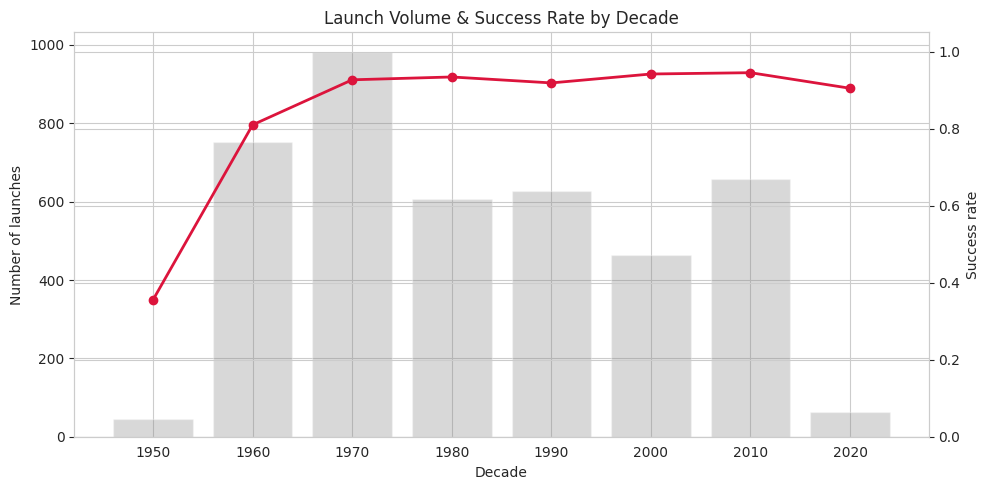

In [17]:
agg = df.groupby("decade")["mission_success"].agg(["mean", "count"]).reset_index()

fig, ax1 = plt.subplots()
ax1.bar(agg["decade"], agg["count"], alpha=0.3, color="gray", width=8, label="Launch count")
ax1.set_ylabel("Number of launches")
ax2 = ax1.twinx()
ax2.plot(agg["decade"], agg["mean"], color="crimson", marker="o", linewidth=2, label="Success rate")
ax2.set_ylabel("Success rate")
ax2.set_ylim(0, 1.05)
ax1.set_xlabel("Decade")
plt.title("Launch Volume & Success Rate by Decade")
plt.tight_layout()
plt.show()

**Observation:** The success rate jumped from ~80% in the 1960s to consistently over 90% from the 1990s onward.

*Modeling Action:* We must implement a **Rolling Reliability Curve** feature for each rocket family. However, to satisfy hackathon constraints, this rolling average must *only* look backward at `t-1` to prevent future data leakage.

## 5. Categorical Feature Analysis
Different rocket configurations and government agencies have varying risk tolerances and safety records.

/tmp/ipykernel_495/2249268029.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg["mean"], y=agg.index, ax=ax, palette="viridis")


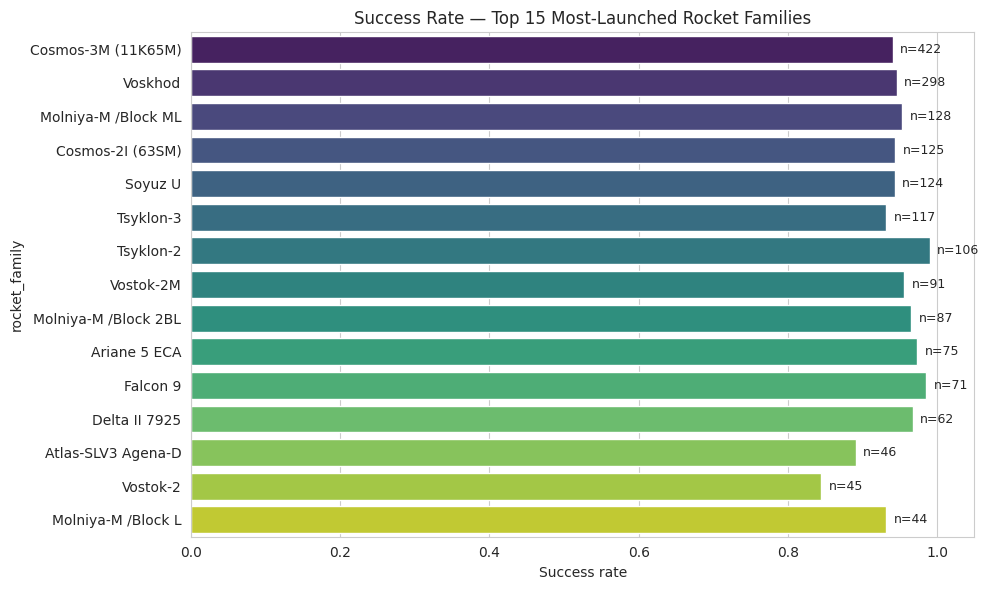

In [18]:
top_families = df["rocket_family"].value_counts().head(15).index
subset = df[df["rocket_family"].isin(top_families)]
agg = subset.groupby("rocket_family")["mission_success"].agg(["mean", "count"]).sort_values("count", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=agg["mean"], y=agg.index, ax=ax, palette="viridis")
ax.set_xlabel("Success rate")
ax.set_xlim(0, 1.05)
ax.set_title("Success Rate — Top 15 Most-Launched Rocket Families")
for i, (rate, count) in enumerate(zip(agg["mean"], agg["count"])):
    ax.text(rate + 0.01, i, f"n={count}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

/tmp/ipykernel_495/781096680.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg["mean"], y=agg.index, ax=ax, palette="mako")


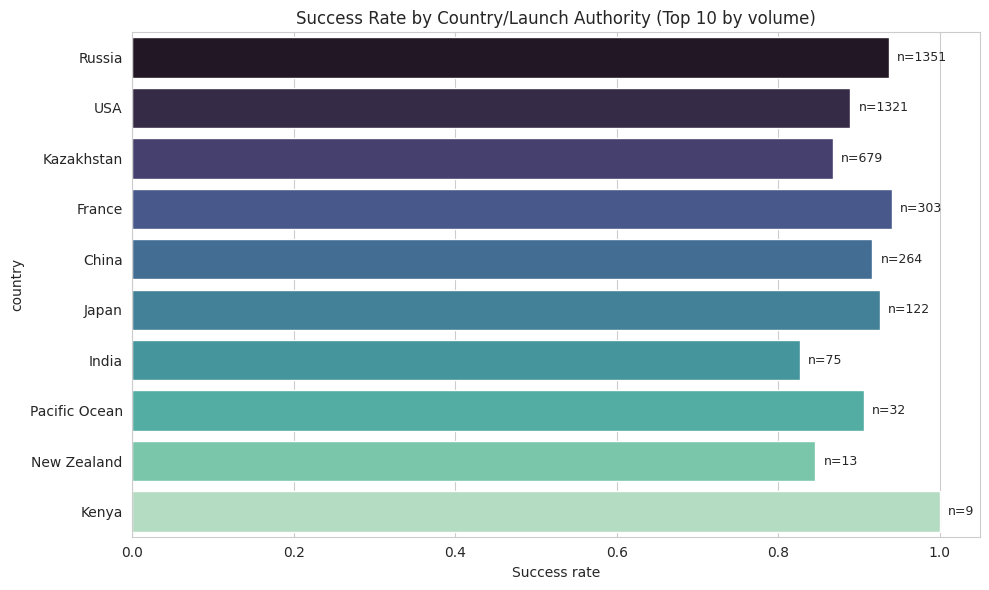

In [19]:
top_countries = df["country"].value_counts().head(10).index
subset = df[df["country"].isin(top_countries)]
agg = subset.groupby("country")["mission_success"].agg(["mean", "count"]).sort_values("count", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=agg["mean"], y=agg.index, ax=ax, palette="mako")
ax.set_xlabel("Success rate")
ax.set_xlim(0, 1.05)
ax.set_title("Success Rate by Country/Launch Authority (Top 10 by volume)")
for i, (rate, count) in enumerate(zip(agg["mean"], agg["count"])):
    ax.text(rate + 0.01, i, f"n={count}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 6. High Cardinality Strategy
Tree-based models (like XGBoost or LightGBM) struggle with high-cardinality categorical variables where categories have very few samples. It leads to severe overfitting. Let's quantify this "long tail" of rare rocket families.

In [20]:
print(f"Total launches: {len(df)}")
print(f"Date range: {df['launch_date'].min().date()} to {df['launch_date'].max().date()}")
print(f"Overall success rate: {df['mission_success'].mean():.2%}")
print(f"Unique rocket families: {df['rocket_family'].nunique()}")
print(f"Unique launch sites: {df['launch_site'].nunique()}")
print(f"Unique countries/agencies: {df['country'].nunique()}")
print("\nTop 5 most active rocket families:")
print(df["rocket_family"].value_counts().head(5))

Total launches: 4198
Date range: 1957-10-04 to 2020-08-07
Overall success rate: 90.38%
Unique rocket families: 339
Unique launch sites: 126
Unique countries/agencies: 21

Top 5 most active rocket families:
rocket_family
Cosmos-3M (11K65M)     422
Voskhod                298
Molniya-M /Block ML    128
Cosmos-2I (63SM)       125
Soyuz U                124
Name: count, dtype: int64


In [21]:
family_counts = df["rocket_family"].value_counts()
print(f"Families with only 1 launch: {(family_counts == 1).sum()}")
print(f"Families with <=5 launches: {(family_counts <= 5).sum()}")
print(f"Families with <=15 launches: {(family_counts <= 15).sum()}")
print(f"\nCumulative launches from top 20 families: {family_counts.head(20).sum()} / {family_counts.sum()} ({family_counts.head(20).sum()/family_counts.sum():.1%})")

Families with only 1 launch: 83
Families with <=5 launches: 199
Families with <=15 launches: 284

Cumulative launches from top 20 families: 2037 / 4198 (48.5%)


In [22]:
family_counts = df["rocket_family"].value_counts()
for threshold in [10, 15, 20, 25]:
    kept = (family_counts > threshold).sum()
    coverage = family_counts[family_counts > threshold].sum() / family_counts.sum()
    print(f"min_count={threshold}: keeps {kept} families, covers {coverage:.1%} of launches")

min_count=10: keeps 91 families, covers 80.5% of launches
min_count=15: keeps 55 families, covers 69.6% of launches
min_count=20: keeps 47 families, covers 66.3% of launches
min_count=25: keeps 36 families, covers 60.3% of launches


**Observation:** Out of 339 unique rocket families, 284 of them have 15 or fewer historical launches.

*Modeling Action:* During our feature engineering pipeline, we will apply **Frequency Thresholding**. Any `rocket_family` or `launch_site` with fewer than 15 historical launches will be bucketed into a unified `'Other'` category. This dramatically reduces feature dimensionality and prevents our model from memorizing random outcomes of obscure rockets.





## 7. Next Steps & Feature Engineering Plan
Based on this EDA, our path forward to meet the MSoC 2026 Hackathon constraints is:
1. **Weather Data Enrichment:** We need to fetch historical NOAA weather data (wind shear, temperature) and merge it using the `launch_date` and `launch_site` coordinates.
2. **Time-Series Leakage Prevention:** We will calculate a `rolling_success_rate` for each rocket family, ensuring the window only includes `[0:t-1]`.
3. **Model Selection:** We will utilize **LightGBM** or **XGBoost** to handle the mixed categorical/numerical data.
4. **Calibration:** We will wrap our classifier in a `CalibratedClassifierCV` (Isotonic regression) to convert raw margin scores into true probabilities.
5. **Explainability:** We will pass our model through a **SHAP** explainer to generate the feature attributions required for the final dashboard.